# Imports

In [ ]:
!pip install scanpy
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 41.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/GP_datasets/HBECs/HBECs.h5ad")
adata

AnnData object with n_obs × n_vars = 17451 × 22100
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio'

In [ ]:

labels = adata.obs["Cell type"]
X = adata.X
print("Number of classes:", labels.nunique())

Number of classes: 14


In [ ]:
labels

,Cell type
p46c_AAACCTGAGACCCACC,Secretory3
p46c_AAACCTGAGGACACCA,Ciliated1
p46c_AAACCTGAGTAACCCT,Goblet
p46c_AAACCTGGTCATCGGC,Goblet
p46c_AAACCTGTCACCCGAG,Ciliated2
...,...
p51c_TTTGTCACACTGCCAG,Secretory3
p51c_TTTGTCAGTTCACGGC,Secretory2
p51c_TTTGTCATCAACCAAC,Basal1
p51c_TTTGTCATCCTTTCTC,Goblet


## Normalization

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Select HVG

seurat_v3 kanet btala3 error "install scikit-misc" after installation same error brdo

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, flavor='seurat')
adata


AnnData object with n_obs × n_vars = 17451 × 2000
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [ ]:
adata.var.head()


,highly_variable,means,dispersions,dispersions_norm
RP11-206L10.2,True,0.002584,1.288738,1.086750
ISG15,True,0.371562,1.800282,2.085923
RP11-465B22.8,True,0.104528,1.288023,1.083944
TTLL10,True,0.150654,1.361609,1.372354
MXRA8,True,0.003010,1.423893,1.616470


## PCA

In [ ]:
sc.tl.pca(adata, n_comps=100)
adata

AnnData object with n_obs × n_vars = 17451 × 2000
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [ ]:

y = labels.values

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

clf = LogisticRegression(max_iter=1500, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.X
y = adata.obs["Cell type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

### Evaluation

=== Logistic Regression ===
Accuracy: 0.8269440146696464
               precision    recall  f1-score   support

       Basal1       0.87      0.89      0.88      1923
       Basal2       0.83      0.84      0.83      1922
       Basal3       0.68      0.67      0.68       556
Basal_Mitotic       0.88      0.75      0.81       305
    Ciliated1       0.94      0.95      0.94      2150
    Ciliated2       0.85      0.80      0.82       614
         Club       0.83      0.84      0.83      3347
        FOXN4       0.90      0.75      0.82        80
   Fibroblast       0.96      0.99      0.98       377
       Goblet       0.79      0.78      0.78       980
     Ionocyte       0.96      0.86      0.91       124
   Secretory1       0.73      0.75      0.74      1728
   Secretory2       0.78      0.79      0.79      2871
   Secretory3       0.71      0.70      0.71       474

     accuracy                           0.83     17451
    macro avg       0.84      0.81      0.82     17451
 weigh

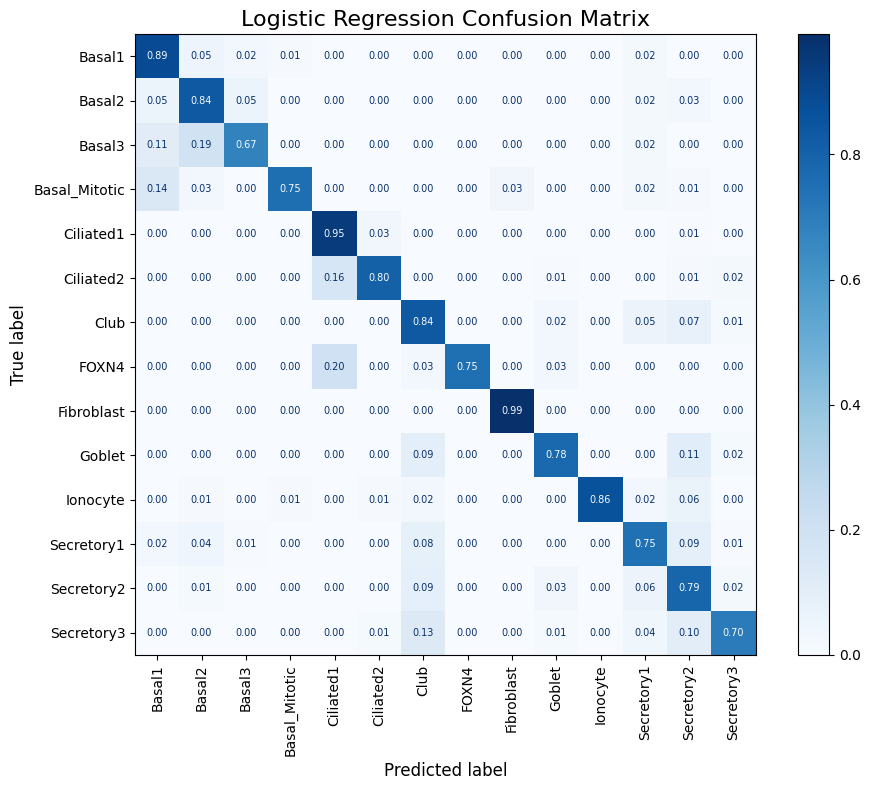


=== k-NN ===
Accuracy: 0.7468339923213569
               precision    recall  f1-score   support

       Basal1       0.72      0.94      0.81      1923
       Basal2       0.87      0.68      0.76      1922
       Basal3       0.90      0.39      0.54       556
Basal_Mitotic       0.99      0.48      0.64       305
    Ciliated1       0.90      0.91      0.91      2150
    Ciliated2       0.89      0.63      0.74       614
         Club       0.62      0.92      0.74      3347
        FOXN4       1.00      0.26      0.42        80
   Fibroblast       0.95      0.99      0.97       377
       Goblet       0.94      0.02      0.03       980
     Ionocyte       1.00      0.58      0.73       124
   Secretory1       0.67      0.84      0.75      1728
   Secretory2       0.79      0.66      0.72      2871
   Secretory3       0.69      0.64      0.66       474

     accuracy                           0.75     17451
    macro avg       0.85      0.64      0.67     17451
 weighted avg       

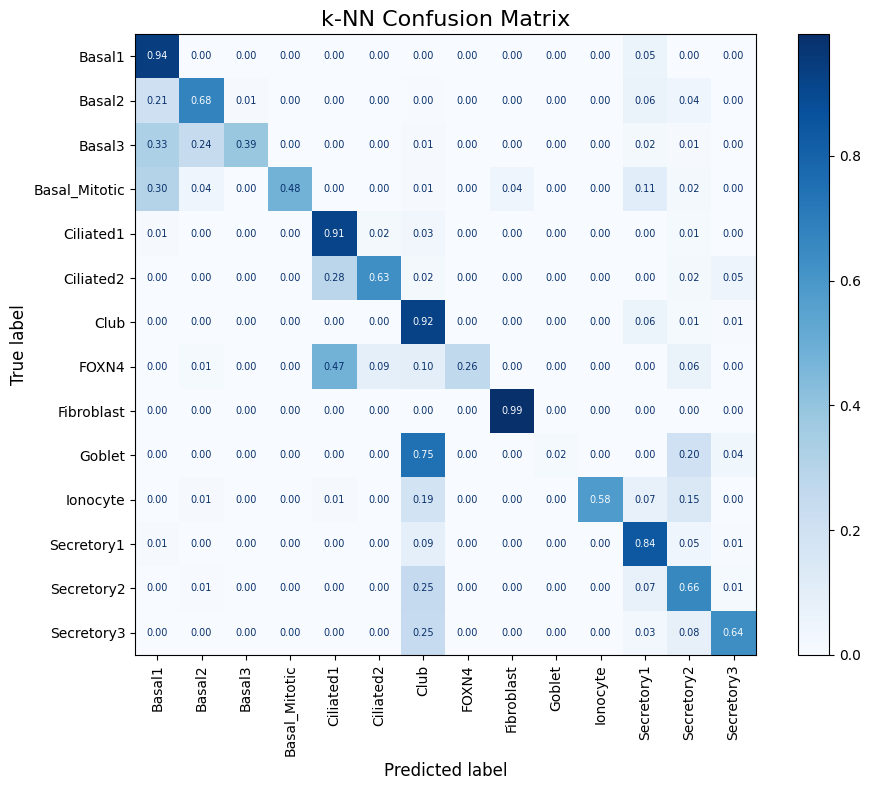

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")
print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

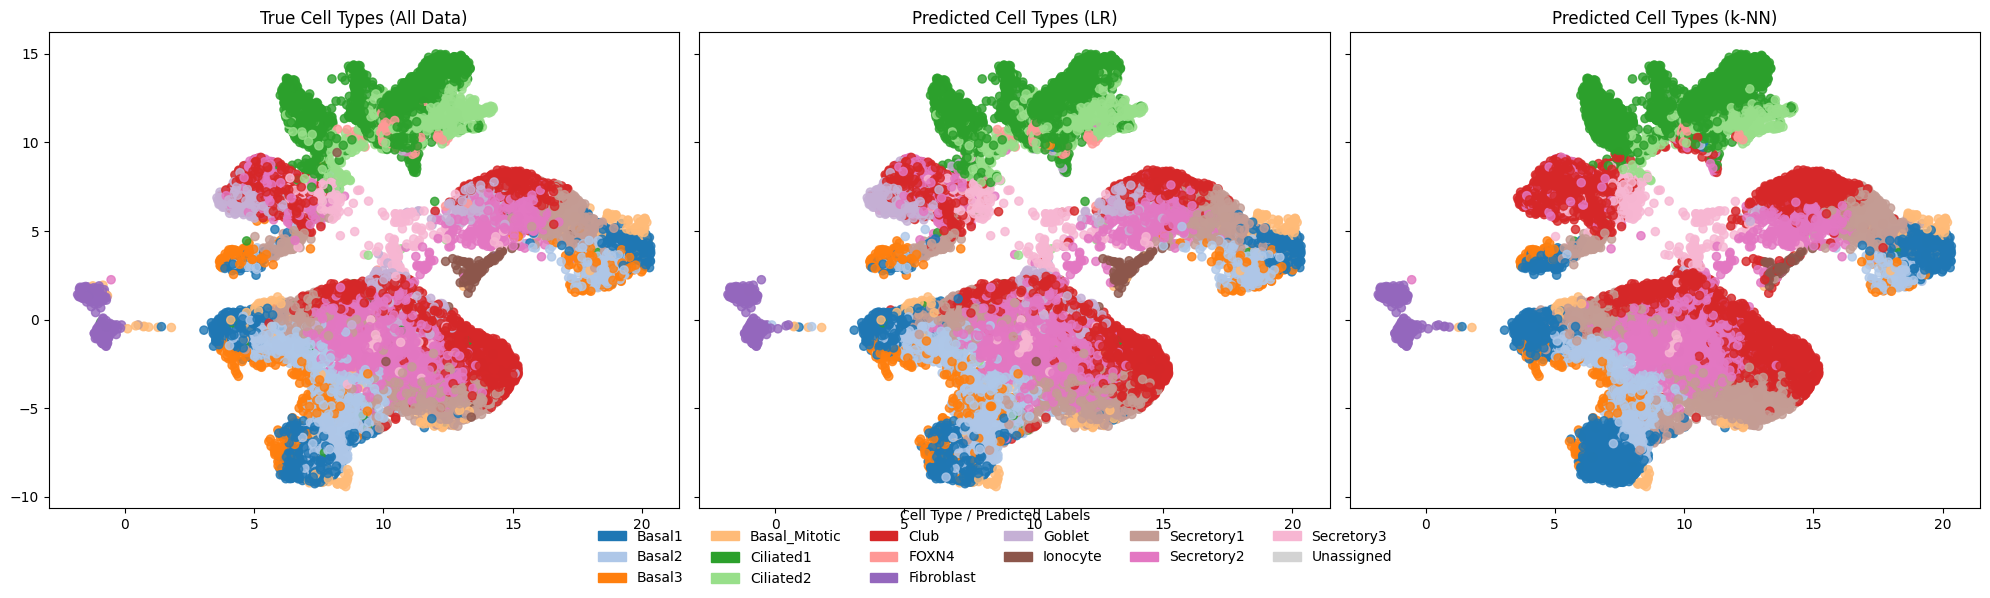

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from matplotlib.patches import Patch

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')

# Compute UMAP (once)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

# Combine all labels
all_labels = np.unique(np.concatenate([
    adata.obs["Cell type"].to_numpy(),
    adata.obs['y_pred_lr'].to_numpy(),
    adata.obs['y_pred_knn'].to_numpy()
]))

# Create consistent color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Add color columns to adata
adata.obs['color_true'] = adata.obs['Cell type'].map(label_to_color)
adata.obs['color_lr'] = adata.obs['y_pred_lr'].map(label_to_color)
adata.obs['color_knn'] = adata.obs['y_pred_knn'].map(label_to_color)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

axes[0].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_true'], s=35, alpha=0.8)
axes[0].set_title('True Cell Types (All Data)')

axes[1].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_lr'], s=35, alpha=0.8)
axes[1].set_title('Predicted Cell Types (LR)')

axes[2].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_knn'], s=35, alpha=0.8)
axes[2].set_title('Predicted Cell Types (k-NN)')

# Shared legend
handles = [Patch(color=color, label=lbl) for lbl, color in label_to_color.items()]
fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
